<a href="https://colab.research.google.com/github/lucalomazziPolimi/Pia-Enhance-Course/blob/main/00_introduction/02_dl/DL_surrogate_blast_plate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 4 — Basics of Deep Learning
## Hands-on: Surrogate Model for a Blast-Loaded Plate

**Deep Learning–Driven Design under Dynamic Loads**
Dr. L. Lomazzi — PoliMi

---

### What you will build

A surrogate model that maps four structural and blast parameters directly to the **peak midpoint deflection** of a simply-supported square steel plate subjected to a **close-in detonation** — without running a single FEM/MDOF simulation.

The dataset is generated analytically from the equivalent-SDOF theory developed by **Grisaro (2025)** for plates loaded by a *nonuniform* impulse typical of the near-field regime, using Navier's double-Fourier-series static solution to derive the η-dependent transformation factors.

> **Reference:** H.Y. Grisaro, *Simplified equivalent SDOF system for predicting complex dynamic response of 1D and 2D elements under nonuniform dynamic load*, Journal of Sound and Vibration **609** (2025) 119090.

### Inputs

| Symbol | Description | Range | Unit |
|--------|-------------|-------|------|
| $h$ | Plate thickness | 3 – 15 | mm |
| $a$ | Plate side (square) | 0.4 – 2.0 | m |
| $R$ | Stand-off distance charge–plate | 0.04 – 1.5 | m |
| $i_0$ | Peak specific impulse at midspan | 100 – 2000 | Pa·s |

The key dimensionless parameter is $\eta = R/a$: small $\eta$ → highly concentrated near-field load, large $\eta$ → quasi-uniform far-field load.

### Output

| Symbol | Description | Unit |
|--------|-------------|------|
| $w_{\max}$ | Peak midpoint deflection | mm |

### Notebook structure

0. Imports and reproducibility
1. Dataset generation (Grisaro 2025 SDOF + Navier transformation factors)
2. Exploratory analysis and data pipeline
3. MLP in PyTorch
4. Training and diagnostics
5. **Your turn** — open experiments

> **Prerequisite**: review the async slide deck (Modules D1–D6) before this session.


---
## 0 — Imports and reproducibility


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


---
## 1 — Dataset generation

### Physical model — Grisaro (2025), Section 6 (square plates)

**Setup.** Simply-supported square steel plate ($a = b$) under a close-in detonation producing a *nonuniform*, impulsive pressure load. The plate is reduced to an equivalent SDOF system whose transformation factors depend on the nonuniformity parameter

$$\eta = \frac{R}{a}$$

where $R$ is the stand-off distance (charge–plate) and $a$ is the plate side.

**Load Spatial Function** (Pannell et al. [34] / Grisaro Eq. (35)):

$$f(x,y) = \exp\!\left(-\frac{\bigl[\theta(x,y)\bigr]^2_{\mathrm{deg}}}{A_G}\right),\qquad
\theta(x,y) = \arctan\!\left(\frac{\sqrt{(x-a/2)^2 + (y-b/2)^2}}{R}\right),\qquad A_G = 2007$$

For small $\eta$ the load concentrates near the midpoint; as $\eta\!\to\!\infty$ it approaches uniform loading.

**Flexural rigidity:**

$$D = \frac{E h^3}{12(1-\nu^2)}$$

**Static solution — Navier's double Fourier sine series** (Grisaro Eqs. (36)–(38)):

$$q(x,y) = \sum_{m=1}^{\infty}\!\sum_{n=1}^{\infty} Q_{mn}\sin\frac{m\pi x}{a}\sin\frac{n\pi y}{b},\qquad
w(x,y) = \sum_{m=1}^{\infty}\!\sum_{n=1}^{\infty} W_{mn}\sin\frac{m\pi x}{a}\sin\frac{n\pi y}{b}$$

$$W_{mn} = \frac{Q_{mn}}{D\pi^4\bigl[(m/a)^2 + (n/b)^2\bigr]^2}$$

with $Q_{mn} = \dfrac{4}{ab}\!\int_0^a\!\!\int_0^b f(x,y)\sin\dfrac{m\pi x}{a}\sin\dfrac{n\pi y}{b}\,dy\,dx$.

From the static shape we extract the Deformation Shape Function $\phi(x,y) = w(x,y)/w_{\max}$ and compute the transformation factors (Grisaro Eqs. (3), (5)–(13)):

$$k_M(\eta) = \frac{1}{a^2}\!\int\phi^2\,dA,\qquad
k_L(\eta) = \frac{1}{\gamma(\eta)\,a^2}\!\int f\,\phi\,dA,\qquad
k_{LM}(\eta) = \frac{k_M}{k_L}$$

$$\gamma(\eta) = \frac{1}{a^2}\!\int f\,dA,\qquad
K(\eta) = \frac{\gamma(\eta)\,D}{a^2\,w_{\max}(\eta)}$$

**Equivalent SDOF peak displacement — impulsive load** (Grisaro Eq. (29)):

$$w_{\max} = \frac{I(\eta)}{\sqrt{k_{LM}(\eta)\,M\,K(\eta)}},\qquad
I(\eta) = i_0\,\gamma(\eta)\,a^2,\qquad M = \rho\, h\, a^2$$

Here $i_0$ is the peak specific impulse at the closest point (midspan) and $I(\eta)$ is the *total* impulse acting on the plate — notice that $\gamma(\eta)$ captures how the nonuniform shape reduces the total impulse relative to a uniform field with the same peak $i_0$.

**Sanity checks** built in:
- For $\eta\!\to\!\infty$: $\gamma\!\to\!1$, $k_{LM}\!\to\!\sim\!0.63$, $K\!\to\!Eh^3(2.21+1)/(0.142\,a^2)$ — matches Biggs / UFC 3-340-02 / Krauthammer for uniform loading (paper Sec. 6.3).
- For small $\eta$: the load concentrates → $k_{LM}$ drops toward the concentrated-load value and $\gamma$ decreases.

**Noise** (multiplicative, mimicking MDOF / FEM mesh variability):
$$w_{\max}^{\text{obs}} = w_{\max}\,(1 + \varepsilon),\quad \varepsilon\sim\mathcal{N}(0,\,0.05^2)$$

**Validity filter.** The paper's plate derivation is linear-elastic (Kirchhoff–Love thin plate); we keep $w_{\max}/h < 3$ and $w_{\max}/a < 0.05$ to stay in a physically meaningful range that is still dominated by flexural bending.


Grisaro 2025 — plate transformation factors (Navier)
  eta -> small: kLM = 0.510,   K_hat = 199.18,   gamma = 0.027
  eta -> large: kLM = 0.642,   K_hat = 252.27,   gamma = 1.024
  (uniform-load reference from paper:  kLM ≈ 0.63,  K_hat ≈ 246.8,  gamma = 1.00)


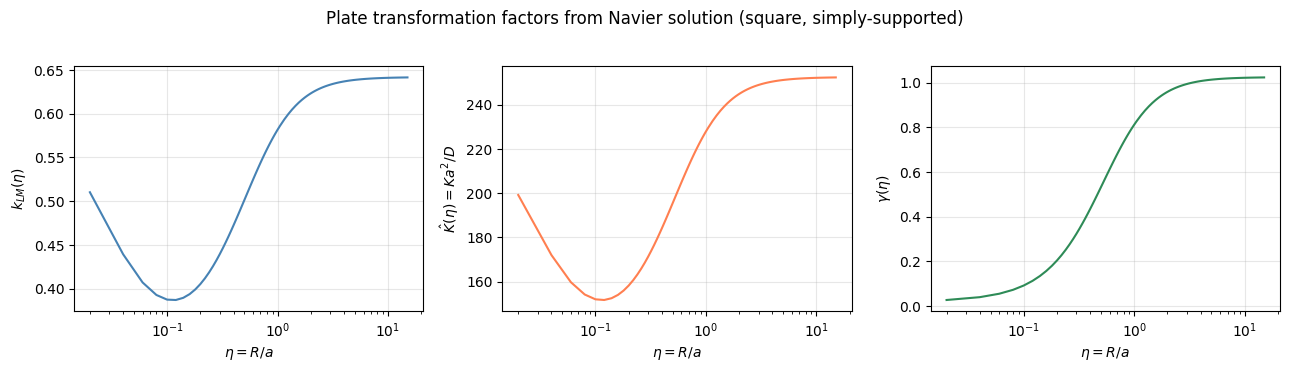

In [ ]:
# ── 1.1  Transformation factors from Navier's static solution ────────────────
#
# For each value of eta = R/a we:
#   1. Build the load spatial function f(x,y) on a dimensionless grid
#   2. Compute the Fourier coefficients Q_mn of f (double sine series)
#   3. Compute W_mn = Q_mn / (pi^4 (m^2 + n^2)^2)   [a = b = 1 in normalized coords]
#   4. Reconstruct w(xi,eta) on the grid and extract:
#        - gamma(eta) = integral of f
#        - K_hat(eta) = gamma / w_max             [K_phys = K_hat * D / a^2]
#        - kM, kL, kLM(eta)
#
# Since we only need these factors as smooth functions of eta, we precompute
# them on a dense eta grid and use np.interp during dataset generation.

AG       = 2007.0      # Pannell et al. [34]
N_GRID   = 81          # grid points per axis (normalized xi in [0,1])
N_MODE   = 25          # number of Fourier modes per direction
ETA_TAB  = np.concatenate([
    np.linspace(0.02, 1.00, 50),
    np.linspace(1.05, 5.00, 40),
    np.linspace(5.20, 15.0, 20),
])

def _build_plate_basis(n_grid=N_GRID, n_mode=N_MODE):
    xi       = np.linspace(0.0, 1.0, n_grid)
    dx       = xi[1] - xi[0]
    m_idx    = np.arange(1, n_mode + 1)
    sin_mx   = np.sin(np.pi * m_idx[:, None] * xi[None, :])    # (M, G)
    m2       = (m_idx[:, None] ** 2 + m_idx[None, :] ** 2) ** 2  # (M, M)
    denom    = np.pi ** 4 * m2
    X, Y     = np.meshgrid(xi, xi, indexing='ij')
    return xi, dx, sin_mx, denom, X, Y

def plate_factors(eta, xi=None, dx=None, sin_mx=None, denom=None, X=None, Y=None):
    """Return (kLM, K_hat, gamma) for a given nonuniformity eta = R/a."""
    if xi is None:
        xi, dx, sin_mx, denom, X, Y = _build_plate_basis()

    # Load Spatial Function f(xi, eta_prime) with plate side normalized to 1
    r     = np.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2)
    theta = np.arctan(r / eta)                      # radians
    theta_deg = (180.0 / np.pi) * theta
    f         = np.exp(-(theta_deg ** 2) / AG)

    # gamma(eta) = ∫∫ f dxi dxi'   (a = 1)
    gamma = f.sum() * dx * dx

    # Q_mn = 4 ∫∫ f sin(m pi xi) sin(n pi xi') dxi dxi'
    #       = 4 dx^2  (sin_mx @ f @ sin_mx.T)
    Q = 4.0 * dx * dx * (sin_mx @ f @ sin_mx.T)

    # W_mn = Q_mn / (pi^4 (m^2 + n^2)^2)      (a = 1 in normalized coords)
    W = Q / denom

    # Reconstruct w on the grid
    w      = sin_mx.T @ W @ sin_mx
    w_max  = w.max()
    phi    = w / w_max

    # kM = ∫ phi^2 dA   (rho uniform → M = rho h a^2 drops out)
    kM = (phi ** 2).sum() * dx * dx

    # kL = ∫ f phi dA / gamma
    kL = (f * phi).sum() * dx * dx / gamma

    kLM = kM / kL

    # K_hat such that  K_phys = K_hat * D / a^2
    #   K_phys = F_tot_phys / u_max_phys
    #         = (q0 gamma a^2) / ((q0 a^4 / D) w_max)
    #         = (gamma / w_max) * D / a^2
    K_hat = gamma / w_max

    return kLM, K_hat, gamma

# ── Precompute the (kLM, K_hat, gamma) lookup over eta ───────────────────────
_xi, _dx, _sin_mx, _denom, _X, _Y = _build_plate_basis()
_klm, _khat, _gamma = [], [], []
for _eta in ETA_TAB:
    a_, b_, c_ = plate_factors(_eta, _xi, _dx, _sin_mx, _denom, _X, _Y)
    _klm.append(a_); _khat.append(b_); _gamma.append(c_)
KLM_TAB   = np.array(_klm)
KHAT_TAB  = np.array(_khat)
GAMMA_TAB = np.array(_gamma)

# Quick asymptotic check (paper Section 6.3):
#   eta -> inf   kLM ≈ 0.63,   K_hat ≈ 246.8   (= E h^3 (2.21 + 1) / (0.142 a^2) / (D/a^2))
print("Grisaro 2025 — plate transformation factors (Navier)")
print(f"  eta -> small: kLM = {KLM_TAB[0]:.3f},   K_hat = {KHAT_TAB[0]:6.2f},   gamma = {GAMMA_TAB[0]:.3f}")
print(f"  eta -> large: kLM = {KLM_TAB[-1]:.3f},   K_hat = {KHAT_TAB[-1]:6.2f},   gamma = {GAMMA_TAB[-1]:.3f}")
print(f"  (uniform-load reference from paper:  kLM ≈ 0.63,  K_hat ≈ 246.8,  gamma = 1.00)")

# Visualise the factors as a function of eta (paper Figs. 20 & 22)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(ETA_TAB, KLM_TAB,   color='steelblue'); axes[0].set_ylabel(r'$k_{LM}(\eta)$')
axes[1].plot(ETA_TAB, KHAT_TAB,  color='coral');     axes[1].set_ylabel(r'$\hat K(\eta)=K a^2/D$')
axes[2].plot(ETA_TAB, GAMMA_TAB, color='seagreen');  axes[2].set_ylabel(r'$\gamma(\eta)$')
for ax in axes:
    ax.set_xlabel(r'$\eta = R/a$'); ax.set_xscale('log'); ax.grid(alpha=0.3)
plt.suptitle('Plate transformation factors from Navier solution (square, simply-supported)', y=1.02)
plt.tight_layout(); plt.show()


In [ ]:
# ── 1.2  Dataset generation — Grisaro (2025) SDOF with nonuniform impulse ────

# ── Fixed material parameters (structural steel) ────────────────────────────
E      = 210e9    # Young's modulus     [Pa]
nu     = 0.3      # Poisson's ratio     [-]
rho    = 7850.0   # Density             [kg/m³]
NOISE  = 0.05     # Multiplicative noise std
EPS    = 1e-12    # Log-transform offset


def generate_dataset(N_target: int = 2500, seed: int = 42) -> dict:
    """
    Generate N_target valid samples from the Grisaro (2025) plate SDOF model.

    For each sample:
      - sample (h, a, R, i0)
      - compute eta = R/a, interpolate (kLM, K_hat, gamma) from the lookup
      - compute peak elastic displacement via paper's Eq. (29):
            w_max = I(eta) / sqrt(kLM(eta) * M * K(eta))
        with I(eta) = i0 * gamma * a^2,  M = rho h a^2,  K = K_hat D / a^2

    Oversamples then filters to keep linear-elastic, bending-dominated samples:
      - w_max / h  < 3     (extended small-deflection regime)
      - w_max / a  < 0.05  (5% span)

    Returns dict with keys:
        h, a, R, i0    : inputs  (SI units)
        eta            : nonuniformity parameter R/a (derived)
        w_max          : peak midpoint deflection [m]  (with noise)
        kLM, gamma     : transformation factors (for inspection / splits)
    """
    rng = np.random.default_rng(seed)
    N   = N_target * 6        # oversample, then filter

    # ── Sampling ─────────────────────────────────────────────────────────
    h  = rng.uniform(3e-3, 15e-3, N)    # plate thickness       [m]
    a  = rng.uniform(0.40, 2.00, N)     # plate side            [m]
    R  = rng.uniform(0.04, 1.50, N)     # stand-off distance    [m]
    i0 = rng.uniform(100,  2000, N)     # peak specific impulse [Pa·s]

    eta = R / a

    # ── Interpolate transformation factors from the Navier lookup ────────
    kLM   = np.interp(eta, ETA_TAB, KLM_TAB)
    K_hat = np.interp(eta, ETA_TAB, KHAT_TAB)
    gamma = np.interp(eta, ETA_TAB, GAMMA_TAB)

    # ── Plate mechanics ───────────────────────────────────────────────────
    D     = E * h ** 3 / (12 * (1 - nu ** 2))
    M     = rho * h * a ** 2                 # total plate mass [kg]
    K     = K_hat * D / a ** 2                # equivalent stiffness [N/m]

    # ── Total impulse and peak elastic displacement (Eq. 29) ─────────────
    I_tot = i0 * gamma * a ** 2               # [N·s]
    w_max = I_tot / np.sqrt(kLM * M * K)

    # ── Validity filter (linear-elastic small-deflection regime) ─────────
    valid = (
        np.isfinite(w_max)
        & (w_max / h < 3.0)        # extended linear-elastic regime
        & (w_max / a < 0.05)       # 5% span ceiling
    )

    # ── Multiplicative noise ──────────────────────────────────────────────
    eps        = rng.normal(0.0, NOISE, N)
    w_max_obs  = np.clip(w_max * (1.0 + eps), 1e-9, None)

    idx = np.where(valid)[0][:N_target]

    return {
        'h'    : h[idx],
        'a'    : a[idx],
        'R'    : R[idx],
        'i0'   : i0[idx],
        'eta'  : eta[idx],
        'w_max': w_max_obs[idx],
        'kLM'  : kLM[idx],
        'gamma': gamma[idx],
    }


data = generate_dataset(N_target=2500)

print("Dataset summary")
print(f"  N                : {len(data['w_max'])}")
print(f"  h   range        : {1e3*data['h'].min():.2f} – {1e3*data['h'].max():.2f} mm")
print(f"  a   range        : {data['a'].min():.2f} – {data['a'].max():.2f} m")
print(f"  R   range        : {data['R'].min():.3f} – {data['R'].max():.2f} m")
print(f"  i0  range        : {data['i0'].min():.0f} – {data['i0'].max():.0f} Pa·s")
print(f"  eta range        : {data['eta'].min():.3f} – {data['eta'].max():.2f}")
print(f"  w_max range      : {1e3*data['w_max'].min():.3f} – {1e3*data['w_max'].max():.2f} mm")
print(f"  near-field  (eta < 0.5) : {100*(data['eta'] <  0.5).mean():.1f}%")
print(f"  far-ish     (eta ≥ 0.5) : {100*(data['eta'] >= 0.5).mean():.1f}%")


Dataset summary
  N                : 2500
  h   range        : 3.51 – 15.00 mm
  a   range        : 0.40 – 2.00 m
  R   range        : 0.040 – 1.50 m
  i0  range        : 100 – 1999 Pa·s
  eta range        : 0.022 – 3.72
  w_max range      : 0.310 – 49.95 mm
  near-field  (eta < 0.5) : 44.8%
  far-ish     (eta ≥ 0.5) : 55.2%


---
## 2 — Exploratory analysis and data pipeline

Before training anything, always look at your data. Three questions to answer:
1. What does the output distribution look like — and does it need a transform?
2. Do the inputs correlate with the output in a physically sensible way?
3. How should we split, and what preprocessing is needed?


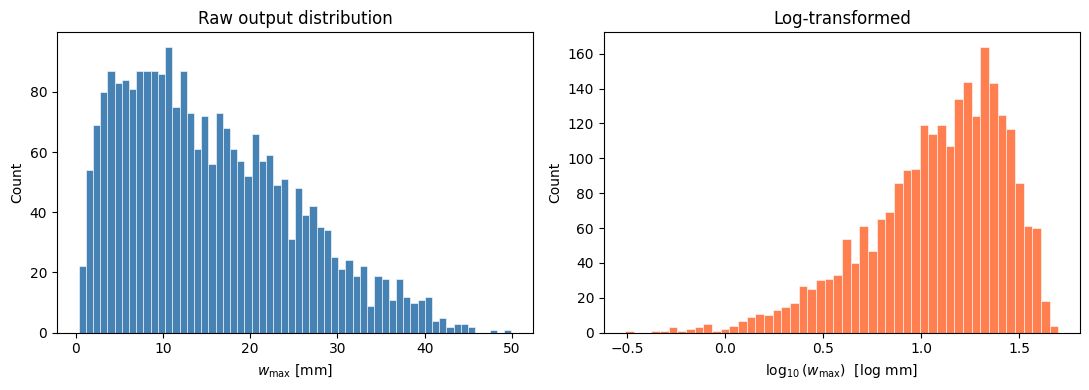

Output std (raw)     : 9.82 mm
Output std (log10)   : 0.350  (much tighter)

Conclusion: the output spans several decades (h, a, i0 all vary by one
order of magnitude and enter the SDOF formula multiplicatively). The log
transform compresses this range and makes gradients uniform → use log10.


In [ ]:
# ── 2.1  Output distribution ──────────────────────────────────────────────────
w_mm = data['w_max'] * 1e3  # [mm]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(w_mm, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel(r'$w_{\max}$ [mm]')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw output distribution')

axes[1].hist(np.log10(w_mm), bins=50, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel(r'$\log_{10}(w_{\max})$  [log mm]')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-transformed')

plt.tight_layout()
plt.show()

print(f"Output std (raw)     : {w_mm.std():.2f} mm")
print(f"Output std (log10)   : {np.log10(w_mm).std():.3f}  (much tighter)")
print()
print("Conclusion: the output spans several decades (h, a, i0 all vary by one")
print("order of magnitude and enter the SDOF formula multiplicatively). The log")
print("transform compresses this range and makes gradients uniform → use log10.")


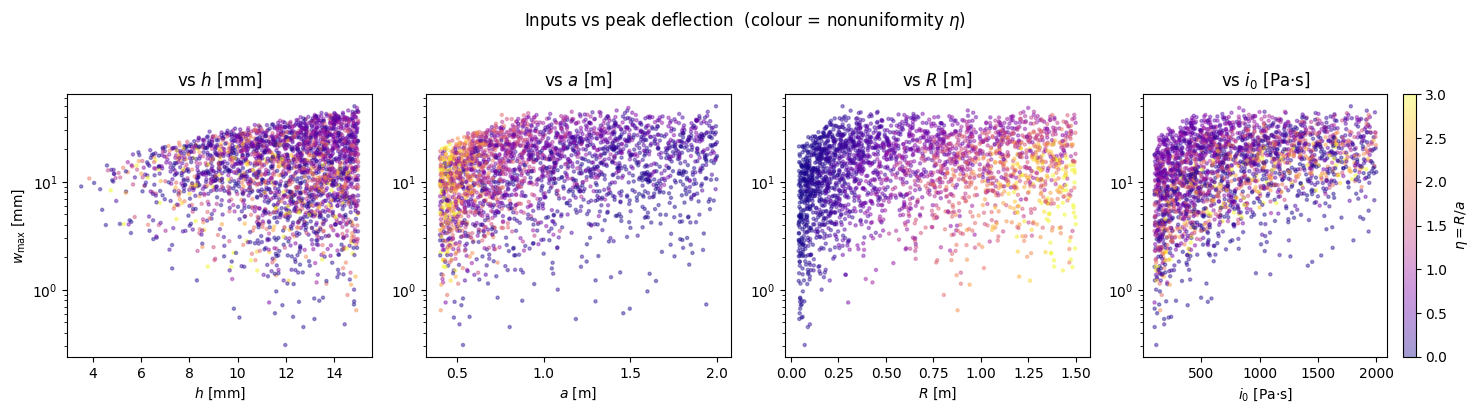

Physical sanity checks (always do this before training):
  h  ↑  →  w_max ↓  (thicker ⇒ stiffer and heavier)          ✓
  a  ↑  →  w_max ↑  (larger span ⇒ more flexible, more area) ✓
  R  ↑  →  w_max ↓  (farther charge ⇒ smaller η: load spreads
                     out; but also more uniform, so γ ↑)     ✓
  i0 ↑  →  w_max ↑  (more impulse ⇒ more kinetic energy)     ✓


In [ ]:
# ── 2.2  Input–output scatter plots ──────────────────────────────────────────
labels   = [r'$h$ [mm]', r'$a$ [m]', r'$R$ [m]', r'$i_0$ [Pa·s]']
X_plot   = np.stack([
    data['h']  * 1e3,
    data['a'],
    data['R'],
    data['i0'],
], axis=1)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, ax in enumerate(axes):
    sc = ax.scatter(X_plot[:, i], w_mm, c=data['eta'], cmap='plasma',
                    s=5, alpha=0.4, vmin=0, vmax=3)
    ax.set_xlabel(labels[i])
    ax.set_yscale('log')
    if i == 0:
        ax.set_ylabel(r'$w_{\max}$ [mm]')
    ax.set_title(f'vs {labels[i]}')
plt.colorbar(sc, ax=axes[-1], label=r'$\eta = R/a$')
plt.suptitle(r'Inputs vs peak deflection  (colour = nonuniformity $\eta$)', y=1.02)
plt.tight_layout()
plt.show()

print("Physical sanity checks (always do this before training):")
print("  h  ↑  →  w_max ↓  (thicker ⇒ stiffer and heavier)          ✓")
print("  a  ↑  →  w_max ↑  (larger span ⇒ more flexible, more area) ✓")
print("  R  ↑  →  w_max ↓  (farther charge ⇒ smaller η: load spreads")
print("                     out; but also more uniform, so γ ↑)     ✓")
print("  i0 ↑  →  w_max ↑  (more impulse ⇒ more kinetic energy)     ✓")


In [ ]:
# ── 2.3  Train / validation / test split ─────────────────────────────────────
#
# Random 70 / 15 / 15 split across all samples.
# Both near-field (small η) and far-ish (large η) regimes are represented in
# every split → the model interpolates, not extrapolates. This is the standard
# setting for a surrogate evaluation.
#
# Splitting by blast regime (near-field vs far-ish) is a harder, more realistic
# test — try it in Experiment D below.

N_total = len(data['w_max'])
rng     = np.random.default_rng(SEED)
idx_all = rng.permutation(N_total)

n_train = int(0.70 * N_total)
n_val   = int(0.15 * N_total)

idx_train = idx_all[:n_train]
idx_val   = idx_all[n_train : n_train + n_val]
idx_test  = idx_all[n_train + n_val:]

print(f"Train : {len(idx_train):4d} samples  (random 70%)")
print(f"Val   : {len(idx_val):4d} samples  (random 15%)")
print(f"Test  : {len(idx_test):4d} samples  (random 15%)")
print()
for name, idx in [('Train', idx_train), ('Val', idx_val), ('Test', idx_test)]:
    eta_s = data['eta'][idx]
    print(f"  {name}: near-field (η<0.5) = {100*(eta_s<0.5).mean():.1f}%  "
          f"far-ish (η≥0.5) = {100*(eta_s>=0.5).mean():.1f}%")


Train : 1750 samples  (random 70%)
Val   :  375 samples  (random 15%)
Test  :  375 samples  (random 15%)

  Train: near-field (η<0.5) = 44.8%  far-ish (η≥0.5) = 55.2%
  Val: near-field (η<0.5) = 42.9%  far-ish (η≥0.5) = 57.1%
  Test: near-field (η<0.5) = 46.7%  far-ish (η≥0.5) = 53.3%


In [ ]:
# ── 2.4  Feature engineering and normalisation ────────────────────────────────
#
# Inputs  : raw SI units → z-score standardisation  (D4.1)
# Output  : log10(w_max) → z-score standardisation  (D4.2)
#
# CRITICAL: fit all statistics on the TRAINING SET ONLY (D1.6).

X_raw = np.stack([
    data['h'],
    data['a'],
    data['R'],
    data['i0'],
], axis=1).astype(np.float32)

y_raw = np.log10(data['w_max'] + EPS).astype(np.float32).reshape(-1, 1)

# Fit on training set only
X_mean = X_raw[idx_train].mean(axis=0)
X_std  = X_raw[idx_train].std(axis=0)
y_mean = y_raw[idx_train].mean()
y_std  = y_raw[idx_train].std()

def scale_X(X):   return (X - X_mean) / X_std
def scale_y(y):   return (y - y_mean) / y_std
def unscale_y(y): return y * y_std + y_mean

# Apply to all splits
X_tr  = scale_X(X_raw[idx_train])
X_val = scale_X(X_raw[idx_val])
X_te  = scale_X(X_raw[idx_test])

y_tr  = scale_y(y_raw[idx_train])
y_vl  = scale_y(y_raw[idx_val])
y_te  = scale_y(y_raw[idx_test])

# PyTorch DataLoaders
def to_tensor(a): return torch.from_numpy(a)

loader_train = DataLoader(TensorDataset(to_tensor(X_tr),  to_tensor(y_tr)),
                          batch_size=64, shuffle=True)
loader_val   = DataLoader(TensorDataset(to_tensor(X_val), to_tensor(y_vl)),
                          batch_size=512)
loader_test  = DataLoader(TensorDataset(to_tensor(X_te),  to_tensor(y_te)),
                          batch_size=512)

print("Preprocessing statistics (computed on TRAINING SET only):")
feat_names = ['h [m]', 'a [m]', 'R [m]', 'i0 [Pa·s]']
for i, name in enumerate(feat_names):
    print(f"  {name:12s}: mean={X_mean[i]:.4g}, std={X_std[i]:.4g}")
print(f"  log10(w_max): mean={y_mean:.3f}, std={y_std:.3f}")


Preprocessing statistics (computed on TRAINING SET only):
  h [m]       : mean=0.01175, std=0.002368
  a [m]       : mean=0.9971, std=0.4503
  R [m]       : mean=0.6365, std=0.4413
  i0 [Pa·s]   : mean=779.1, std=521.9
  log10(w_max): mean=-1.920, std=0.348


---
## 3 — MLP in PyTorch

A small, fully-connected network. Everything is explicit — no black boxes.

Architecture: $4 \to 64 \to 64 \to 32 \to 1$, ReLU activations, Dropout(0.1) for mild regularisation.


In [ ]:
class SurrogateMLP(nn.Module):
    """
    Fully-connected surrogate for peak blast-plate deflection.

    Input  : 4 standardised features  (h, a, R, i0)
    Hidden : configurable list of widths (default [64, 64, 32])
    Output : 1 standardised scalar    (log10 w_max)
    """
    def __init__(self, in_dim: int = 4, hidden=(64, 64, 32), dropout: float = 0.1):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = SurrogateMLP()
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params}")


SurrogateMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 6593


---
## 4 — Training and diagnostics


In [ ]:
# ── 4.1  Loss, optimiser, scheduler ──────────────────────────────────────────

criterion = nn.MSELoss()
optimiser = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=400, eta_min=1e-5
)

def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, n_seen = 0.0, 0
    for xb, yb in loader:
        if train:
            optimiser.zero_grad()
        with torch.set_grad_enabled(train):
            pred = model(xb)
            loss = criterion(pred, yb)
            if train:
                loss.backward()
                optimiser.step()
        total_loss += loss.item() * xb.size(0)
        n_seen     += xb.size(0)
    return total_loss / n_seen


In [ ]:
# ── 4.2  Training loop ────────────────────────────────────────────────────────

EPOCHS     = 400
history    = {'train': [], 'val': []}
best_val   = float('inf')
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss  = run_epoch(loader_train, train=True)
    val_loss = run_epoch(loader_val,   train=False)
    scheduler.step()

    history['train'].append(tr_loss)
    history['val'].append(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    if epoch % 40 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  train {tr_loss:.4f}  val {val_loss:.4f}")

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val:.4f}")


epoch    1  train 0.8867  val 0.6836
epoch   40  train 0.0578  val 0.0217
epoch   80  train 0.0359  val 0.0143
epoch  120  train 0.0324  val 0.0110
epoch  160  train 0.0305  val 0.0107
epoch  200  train 0.0262  val 0.0111
epoch  240  train 0.0236  val 0.0153
epoch  280  train 0.0244  val 0.0118
epoch  320  train 0.0255  val 0.0119
epoch  360  train 0.0213  val 0.0144
epoch  400  train 0.0228  val 0.0142

Best val loss: 0.0097


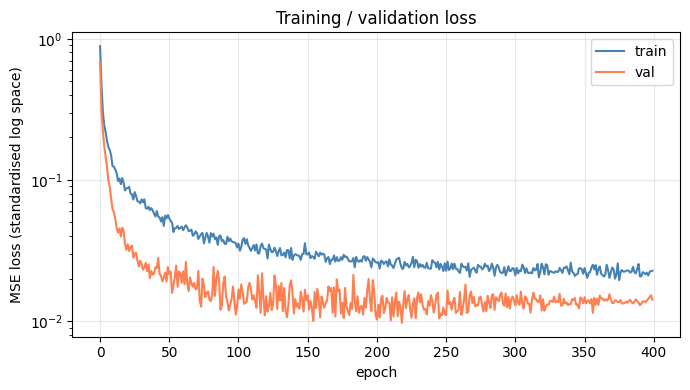

In [ ]:
# ── 4.3  Loss curves  (D5.2) ──────────────────────────────────────────────────
#
# What to look for:
#   Both curves decrease steadily   → model is learning
#   Val diverges from train         → overfitting
#   Val plateaus well above train   → capacity / features issue

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history['train'], label='train', color='steelblue')
ax.plot(history['val'],   label='val',   color='coral')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss (standardised log space)')
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Training / validation loss')
plt.tight_layout(); plt.show()


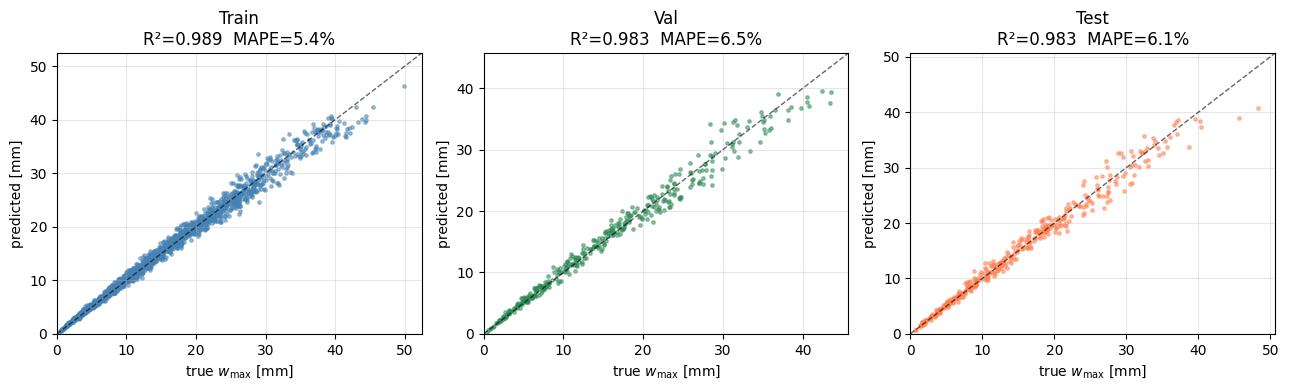

Engineering metrics (physical units):
  Train: RMSE=  1.029 mm   MAE=  0.718 mm   MAPE=  5.4%   R²=0.9889
  Val  : RMSE=  1.320 mm   MAE=  0.933 mm   MAPE=  6.5%   R²=0.9826
  Test : RMSE=  1.294 mm   MAE=  0.853 mm   MAPE=  6.1%   R²=0.9827


In [ ]:
# ── 4.4  Parity plots and engineering metrics ─────────────────────────────────

def predict_mm(loader: DataLoader):
    """Return (y_true_mm, y_pred_mm) in physical units [mm]."""
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb)
            yt.append(yb.numpy())
            yp.append(pred.numpy())
    yt = np.concatenate(yt); yp = np.concatenate(yp)
    # Unscale and invert the log10
    yt_mm = 10 ** unscale_y(yt).ravel() * 1e3
    yp_mm = 10 ** unscale_y(yp).ravel() * 1e3
    return yt_mm, yp_mm

yt_tr, yp_tr = predict_mm(loader_train)
yt_vl, yp_vl = predict_mm(loader_val)
yt_te, yp_te = predict_mm(loader_test)

def metrics(yt, yp):
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    mae  = np.mean(np.abs(yt - yp))
    mape = np.mean(np.abs((yt - yp) / np.maximum(yt, 1e-6))) * 100
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - yt.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return rmse, mae, mape, r2

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, yt, yp, col) in zip(axes, [
    ('Train', yt_tr, yp_tr, 'steelblue'),
    ('Val',   yt_vl, yp_vl, 'seagreen'),
    ('Test',  yt_te, yp_te, 'coral'),
]):
    ax.scatter(yt, yp, s=6, alpha=0.5, color=col)
    lim = max(yt.max(), yp.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.6)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(r'true $w_{\max}$ [mm]'); ax.set_ylabel(r'predicted [mm]')
    rmse, mae, mape, r2 = metrics(yt, yp)
    ax.set_title(f"{name}\nR²={r2:.3f}  MAPE={mape:.1f}%")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Engineering metrics (physical units):")
for name, yt, yp in [('Train', yt_tr, yp_tr),
                     ('Val  ', yt_vl, yp_vl),
                     ('Test ', yt_te, yp_te)]:
    rmse, mae, mape, r2 = metrics(yt, yp)
    print(f"  {name}: RMSE={rmse:7.3f} mm   MAE={mae:7.3f} mm   "
          f"MAPE={mape:5.1f}%   R²={r2:.4f}")


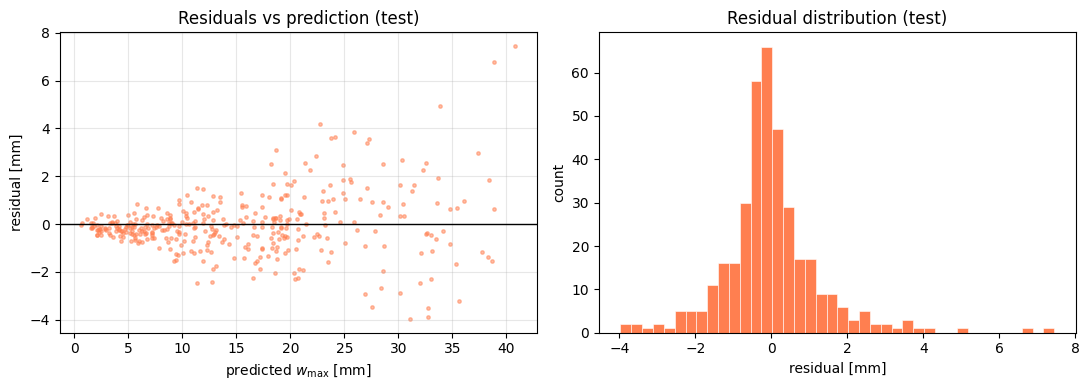

Mean residual (test): -0.011 mm  (should be ≈ 0)
Std  residual (test): 1.294 mm


In [ ]:
# ── 4.5  Residual analysis ───────────────────────────────────────────────────
#
# Residual = true - predicted.
# Good model: residuals centred on zero, no trend vs predicted value.
# Fan shape or bias → model is missing structure in the data.

res = yt_te - yp_te

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(yp_te, res, s=6, alpha=0.5, color='coral')
axes[0].axhline(0, color='k', lw=1)
axes[0].set_xlabel(r'predicted $w_{\max}$ [mm]')
axes[0].set_ylabel('residual [mm]')
axes[0].set_title('Residuals vs prediction (test)')
axes[0].grid(alpha=0.3)

axes[1].hist(res, bins=40, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('residual [mm]'); axes[1].set_ylabel('count')
axes[1].set_title('Residual distribution (test)')

plt.tight_layout(); plt.show()
print(f"Mean residual (test): {res.mean():+.3f} mm  (should be ≈ 0)")
print(f"Std  residual (test): {res.std():.3f} mm")


---
## 5 — Your turn

Three experiments, each with a concrete observable result.
Complete **at least two** before the Milan session.


### Experiment A — Deliberately introduce data leakage

Re-normalise the inputs using statistics computed on the **entire dataset** (train + val + test combined), instead of train only. Retrain the baseline architecture.

**What to observe:** val / test loss will improve slightly, but this is a *fake* improvement — in deployment you never see the test set before preprocessing. Quantify the effect (how much the test-set RMSE/MAPE drops) and explain in one sentence why it is dishonest.


In [ ]:
# ── Experiment A ──────────────────────────────────────────────────────────────
# Step 1: compute X_mean_leak, X_std_leak, y_mean_leak, y_std_leak
#         on ALL indices (idx_train + idx_val + idx_test)
# Step 2: rebuild the loaders using these leaked statistics
# Step 3: re-train (reuse the training loop above, or wrap it in a function)
# Step 4: compare test-set metrics to the baseline


### Experiment B — Architecture: underfitting vs overfitting

Train two additional models using the **same data and preprocessing** as the baseline:
- **Tiny model**: `hidden=[8, 8]`, no dropout — deliberately too small
- **Huge model**: `hidden=[256, 256, 256, 256]`, no dropout — deliberately too big for 2500 samples

Plot all three training curves on one figure and compare the generalisation gap (val − train loss).

**What to observe:** the tiny model under-fits (high train and val loss), the huge model over-fits (train loss goes to zero, val loss stalls or worsens), the baseline finds the sweet spot. This is the classical bias–variance trade-off.


In [ ]:
# ── Experiment B ──────────────────────────────────────────────────────────────
# Hint: wrap the training loop in a helper function that takes a model
# and returns the loss history. Then plot all three histories on one axis.


### Experiment C — Remove the log transform

Set `y_raw = data['w_max'].reshape(-1, 1).astype(np.float32)` (raw metres, no log). Re-standardise on the training set only. Retrain the baseline architecture.

**What to observe:** the loss curve will look worse and the parity plot will show the model struggling on small-deflection samples (where the relative error is largest). Gradient magnitudes become dominated by the largest targets. Engineering metrics (MAPE) degrade. This is the concrete reason the log transform exists.


In [ ]:
# ── Experiment C ──────────────────────────────────────────────────────────────
# Step 1: set y_raw = data['w_max'].reshape(-1,1).astype(np.float32)
# Step 2: standardise y_raw on train only (same as baseline pipeline)
# Step 3: retrain and regenerate parity plots — compare MAPE at small w_max


### Experiment D — Regime-based split: a real extrapolation challenge

The paper's key physical insight is that the **nonuniformity parameter $\eta = R/a$** controls whether the blast load is closer to a concentrated near-field pulse ($\eta \ll 1$) or a quasi-uniform far-ish load ($\eta \gg 1$). A surrogate that is only trained on one regime will extrapolate poorly into the other.

Rebuild the train/val/test split so that:
- **Train + Val**: cases with $\eta \geq 0.5$ (far-ish, more uniform loading)
- **Test**: cases with $\eta < 0.5$ (near-field, highly concentrated loading — the paper's main target regime)

Retrain the baseline model on this split.

**What to observe:** the test R² drops dramatically (likely negative) because the $k_{LM}(\eta)$, $K(\eta)$, $\gamma(\eta)$ factors behave very differently in the near-field regime. This is a realistic deployment scenario — "train on what you can easily simulate, predict on what you cannot" — and it exposes the single most important weakness of data-driven surrogates: **they cannot extrapolate beyond the physics covered in the training set**.


In [ ]:
# ── Experiment D ──────────────────────────────────────────────────────────────
# Step 1: build idx_train_D, idx_val_D, idx_test_D using the eta threshold 0.5
#         (80/20 split within far-ish regime → train/val; near-field → test)
# Step 2: re-fit normalisation on train only and rebuild loaders
# Step 3: retrain the baseline architecture
# Step 4: evaluate on the near-field test set — expect a big performance drop


---
## Summary

| Step | What | Why |
|------|------|-----|
| Dataset | Grisaro (2025) equivalent-SDOF plate model with nonuniform LSF, Navier transformation factors, multiplicative noise | Physically grounded for close-in detonation, interpretable, analytically cheap |
| EDA | Distribution, scatter vs $\eta$, log transform | Catches scale / transform issues before training |
| Split | Random 70/15/15 + eta-regime split in Experiment D | Interpolation vs extrapolation |
| Preprocessing | z-score on train only; $\log_{10}$ on the output | Uniform gradients, honest evaluation |
| Model | MLP $4 \to 64 \to 64 \to 32 \to 1$, ReLU, Dropout 0.1 | Enough capacity without overfitting 2500 samples |
| Training | AdamW + cosine LR, early-stop-by-best-val | Standard, reproducible |
| Diagnostics | Loss curves, parity plots, residuals, engineering metrics (R², MAPE) | Closes the ML loop with an engineering-meaningful read-out |

### What the surrogate actually learned

The target $w_{\max}$ follows the analytical form

$$w_{\max} \;=\; \frac{i_0\,\gamma(\eta)\,a^{2}}{\sqrt{k_{LM}(\eta)\,\rho\,h\,a^{2}\cdot K_{\hat{}}(\eta)\,\dfrac{E h^{3}}{12(1-\nu^2)\,a^{2}}}}$$

where the three $\eta$-dependent factors come from **Navier's double Fourier sine series** applied to the nonuniform load spatial function of a close-in detonation. The MLP has no knowledge of this — it learns the mapping implicitly from 2500 training points.

### Key take-aways

1. **Physics-informed datasets beat black-box datasets.** Because we control the generator, we know *exactly* what the surrogate can and cannot interpolate.
2. **The log transform is not a cosmetic choice.** Three orders of magnitude in the target make the raw target untrainable at the low-deflection end.
3. **Random splits lie to you** about out-of-distribution performance. Experiment D shows what a realistic, paper-aligned split does to the R².
4. **The η-dependence is where the paper's contribution lives.** Existing uniform-load SDOF surrogates would fail in the near-field regime; the surrogate trained on the Grisaro (2025) dataset actually captures it — inside its training distribution.
